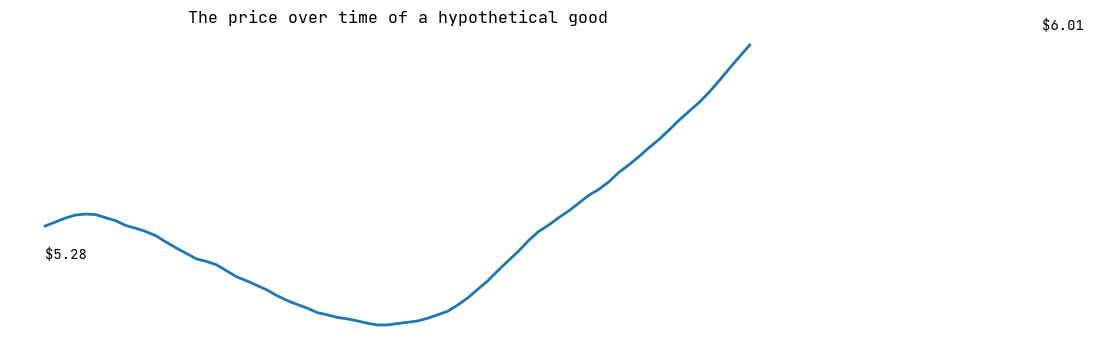

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import pytensor
import pytensor.tensor as pt
import arviz as az
import ipywidgets as widgets
from pymc import vectorize_over_posterior
from pytensor.graph import graph_replace

def build_ar_process(
    n_days=100,
    noise=0.3,
    initial_price=5.0
):
    """
    Build an autoregressive process with repulsion away from 0.
    """
    rng = np.random.default_rng(1234)
    noise = rng.normal(0, noise, n_days)
    beta = 0.95
    repulsion_strength = 0.1

    prices = np.zeros(n_days)
    prices[0] = initial_price

    for i in range(1, n_days):
        repulsive_force = repulsion_strength / prices[i-1]**2
        prices[i] = prices[i-1] + beta * noise[i] + repulsive_force

    return prices

plt.figure(figsize=(10,4))

prices = build_ar_process(noise=0.1,)
prices = np.convolve(prices, np.ones(7)/7, mode='valid')
plt.plot(prices, linewidth=2)

last_value = prices[-1]
plt.text(
    99,
    last_value*1.01,
    f'${round(last_value,2)}',
    fontsize=10,
)
first_value = prices[0]
plt.text(
    0,
    first_value*0.975,
    f'${round(first_value,2)}',
    fontsize=10,
)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.xticks([])
plt.yticks([])
plt.title("The price over time of a hypothetical good");

In [30]:
#| echo: true

# dividing by the mean is like subtracting the mean in additive
# models - it decorrelates intercept and predictor
prices_centered = prices / np.mean(prices)

with pm.Model() as model:
    a = pm.Gamma("a", mu=100, sigma=40)
    b = pm.Normal("b", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)

    prices_pt = pm.Data('x',prices_centered)

    mu = pm.Deterministic('mu',a * prices_pt ** b)

    y = pm.Normal("sales", mu=mu, sigma=sigma)

In [31]:
#| echo: true
a_true = 100
b_true = -1.1
intervention_model = pm.do(model,{'a':a_true,'b':b_true})
observed_sales = pm.draw(intervention_model.sales)

In [32]:
#| echo: true

with pm.observe(model,{"sales":observed_sales}):
    trace = pm.sample(nuts_sampler="nutpie",progressbar=False)

In [8]:
az.summary(trace,var_names=['a','b'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,100.026,0.023,99.984,100.071,0.0,0.0,4740.0,3192.0,1.0
b,-1.105,0.003,-1.109,-1.100,0.0,0.0,5727.0,3292.0,1.0


In [34]:
#| echo: true
# convert demand function to profit function
# unit_profit = unit_price - unit_cost
# total_profit = unit_profit * demand

# c is the unit_cost
c = pt.as_tensor(0.3)
unit_profit = (model.x - c)

# model.mu is the demand
objective = unit_profit * model.mu

# flip sign for optimization
objective = -1 * objective

3.3877551020408165


Text(0.5, 1.0, 'Solution if parameters are known exactly')

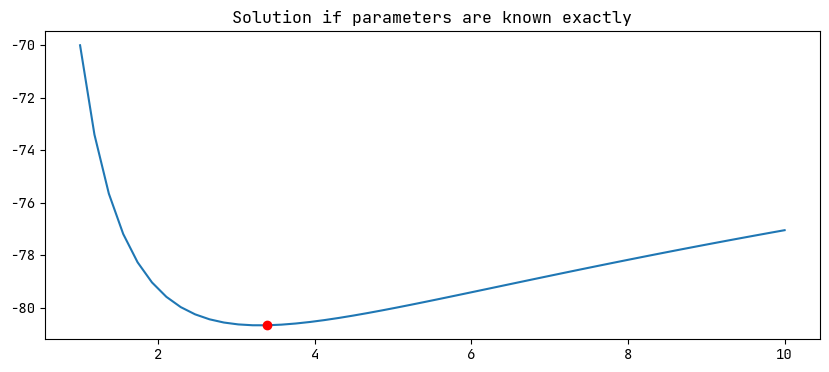

In [35]:
x = np.linspace(1,10)
y = 100 * x**-0.1 - 30 * x ** -1.1
y = -y

min_id = np.argmin(y)
exact_min_val = np.min(y)
exact_min_loc = x[min_id]
print(exact_min_loc)

plt.figure(figsize=(10,4))
plt.plot(x,y)
plt.plot(exact_min_loc,exact_min_val,'ro')
plt.title("Solution if parameters are known exactly")

In [36]:
#| echo: true
from pymc import vectorize_over_posterior

objective = vectorize_over_posterior(
    outputs = [objective],
    posterior = trace.posterior,
    input_rvs=[model.a,model.b]
)[0]

In [37]:
#| echo: true
objective = pt.mean(objective)

In [38]:
#| echo: true
from pytensor.graph import graph_replace

optimizable_x = pt.dvector('opt_x')
objective = graph_replace(objective,replace={model.x:optimizable_x})

In [39]:
#| echo: true
# build gradient and objective function
objective_grad = pt.grad(objective, wrt=optimizable_x)
objective_fn = pytensor.function([optimizable_x], [objective, objective_grad])

Minimum using the expectation of the posterior:  3.0204081632653064


(Text(0.5, 1.0, 'Solution based on expected profit over the posterior distribution'),)

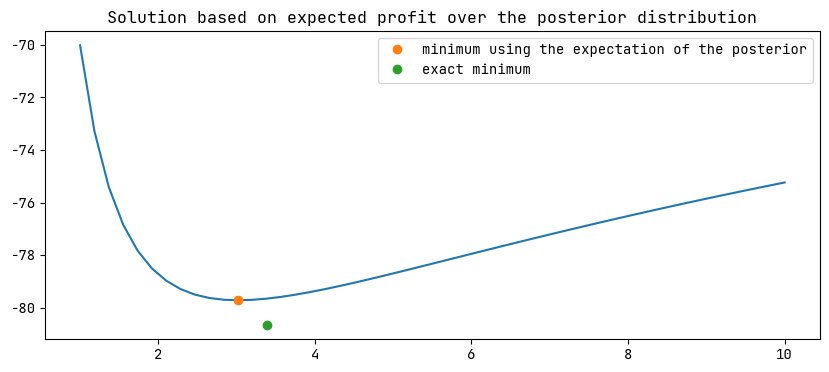

In [40]:
xs = np.linspace(1,10)
y = [float(objective_fn([x])[0]) for x in xs]

min_id = np.argmin(y)
min_val = np.min(y)
min_loc = xs[min_id]
print("Minimum using the expectation of the posterior: ", min_loc)

plt.figure(figsize=(10,4))
plt.plot(xs,y)
plt.plot(min_loc,min_val,'o',label="minimum using the expectation of the posterior")
plt.plot(exact_min_loc,exact_min_val,'o',label="exact minimum")
plt.legend()
plt.title("Solution based on expected profit over the posterior distribution"),

Text(0.5, 1.0, 'Solution based on expected profit over the posterior distribution')

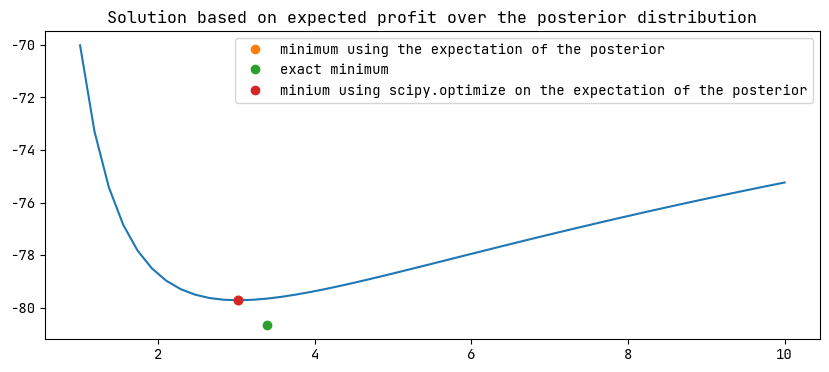

In [41]:
#| echo: true

from scipy.optimize import minimize

res = minimize(
    objective_fn,
    jac=True,
    x0 = [2.50],
    bounds = [(0, None)]
)
plt.figure(figsize=(10,4))
plt.plot(xs,y)
plt.plot(min_loc,min_val,'o',label="minimum using the expectation of the posterior")
plt.plot(exact_min_loc,exact_min_val,'o',label="exact minimum")
plt.plot(res.x[0],res.fun,'o',label="minium using scipy.optimize on the expectation of the posterior")
plt.legend()
plt.title("Solution based on expected profit over the posterior distribution")

# Rich utility functions

Imagine that we sell the product at this price for one year and we need to make at least $28,500 to keep the lights on. We can visualize the uncertainty in profits for a range of prices:

## Uncertainty window

C:\Users\dsaun\AppData\Local\Temp\ipykernel_15284\1803885067.py:27: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdis = az.hdi(y,hdi_prob=0.95)
C:\Users\dsaun\AppData\Local\Temp\ipykernel_15284\1803885067.py:31: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdis = az.hdi(y,hdi_prob=0.50)


Text(0.5, 1.0, 'Uncertainty in profits over one year')

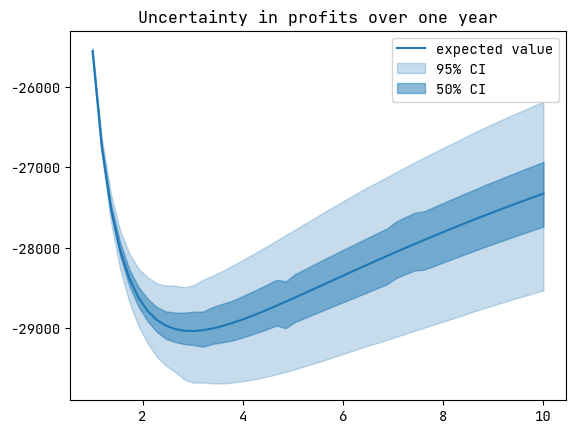

In [54]:
c = pt.as_tensor(0.3)
days = 365
unit_profit = (model.x - c)

objective = days * unit_profit * model.mu
objective = -1 * objective

objective = vectorize_over_posterior(
    outputs = [objective],
    posterior = trace.posterior,
    input_rvs=[model.a,model.b]
)[0]

# objective = pt.mean(objective)

optimizable_x = pt.dvector('opt_x')
objective = graph_replace(objective,replace={model.x:optimizable_x})

# objective_grad = pt.grad(objective, wrt=optimizable_x)
objective_fn = pytensor.function([optimizable_x], [objective])

xs = np.linspace(1,10)
y = [objective_fn([x])[0] for x in xs]
y = np.array(y)
y = np.reshape(y,(50,4000)).T

hdis = az.hdi(y,hdi_prob=0.95)
lower_95 = hdis[:,0]
upper_95 = hdis[:,1]

hdis = az.hdi(y,hdi_prob=0.50)
lower_50 = hdis[:,0]
upper_50 = hdis[:,1]

plt.plot(xs,y.mean(axis=0),label="expected value")
plt.fill_between(xs,lower_95,upper_95,alpha=0.25,label="95% CI",color="tab:blue");
plt.fill_between(xs,lower_50,upper_50,alpha=0.5,label="50% CI",color="tab:blue");
plt.legend()
plt.title("Uncertainty in profits over one year")

## Using a constraint on expected utility

3.0204081632653064


Text(0.5, 1.0, 'Objective surface when we apply the constraint that profits > 28,500')

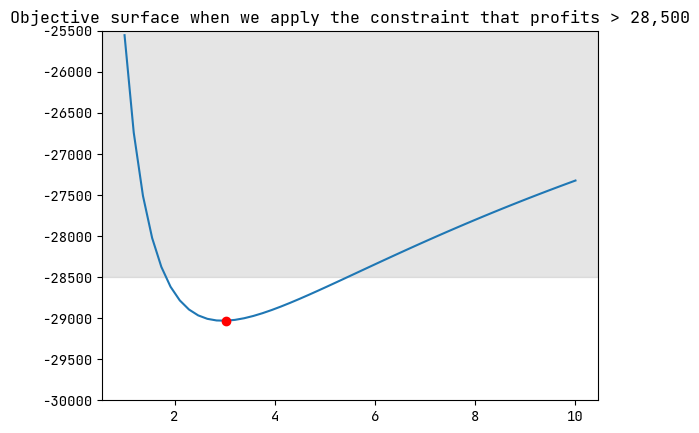

In [19]:
c = pt.as_tensor(0.3)
days = 365
unit_profit = (model.x - c)

objective = days * unit_profit * model.mu
objective = -1 * objective

objective = vectorize_over_posterior(
    outputs = [objective],
    posterior = trace.posterior,
    input_rvs=[model.a,model.b]
)[0]

# We must make at least $28,500 to say alive
# objective = pt.switch(
#     pt.lt(objective, -28_500),
#     objective,
#     0
# )

objective = pt.mean(objective)

optimizable_x = pt.dvector('opt_x')
objective = graph_replace(objective,replace={model.x:optimizable_x})
objective_grad = pt.grad(objective, wrt=optimizable_x)
objective_fn = pytensor.function([optimizable_x], [objective, objective_grad])

xs = np.linspace(1,10)
y = [float(objective_fn([x])[0]) for x in xs]

min_id = np.argmin(y)
min_val = np.min(y)
min_loc = xs[min_id]
print(min_loc)

plt.plot(xs,y)
plt.plot(min_loc,min_val,'ro')
plt.axhspan(ymin=-28_500,ymax=0, color="grey", alpha=0.2)
plt.ylim([-30_000,-25500])
plt.title("Objective surface when we apply the constraint that profits > 28,500")

## Using a utility function on samples that penalized less than 28500

3.3877551020408165


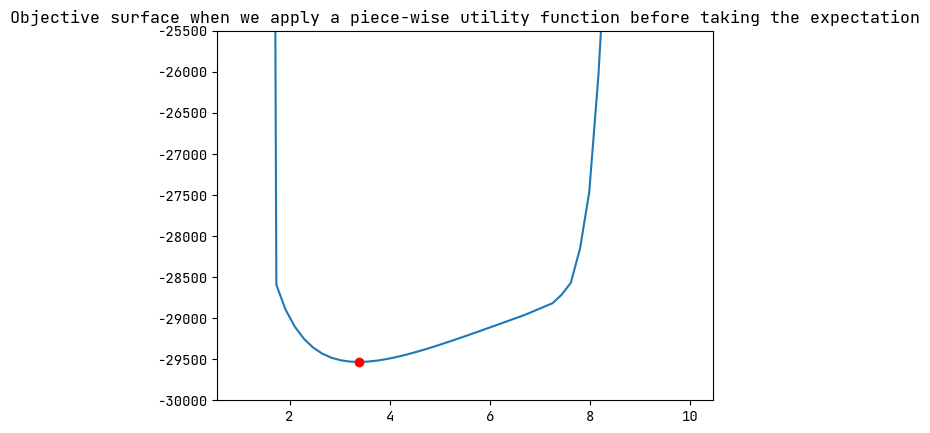

In [17]:
c = pt.as_tensor(0.3)
days = 365
unit_profit = (model.x - c)

objective = days * unit_profit * model.mu
objective = -1 * objective

objective = vectorize_over_posterior(
    outputs = [objective],
    posterior = trace.posterior,
    input_rvs=[model.a,model.b]
)[0]

# We must make at least $28,500 to say alive
objective = pt.switch(
    pt.lt(objective, -28_500),
    objective,
    0
)

objective = pt.mean(objective)

optimizable_x = pt.dvector('opt_x')
objective = graph_replace(objective,replace={model.x:optimizable_x})
objective_grad = pt.grad(objective, wrt=optimizable_x)
objective_fn = pytensor.function([optimizable_x], [objective, objective_grad])

xs = np.linspace(1,10)
y = [float(objective_fn([x])[0]) for x in xs]

min_id = np.argmin(y)
min_val = np.min(y)
min_loc = xs[min_id]
print(min_loc)

plt.plot(xs,y)
plt.plot(min_loc,min_val,'ro')
plt.ylim([-30_000,-25500])
plt.title("Objective surface when we apply a piece-wise utility function before taking the expectation");

## Using a binary classification utility function

1.9183673469387754


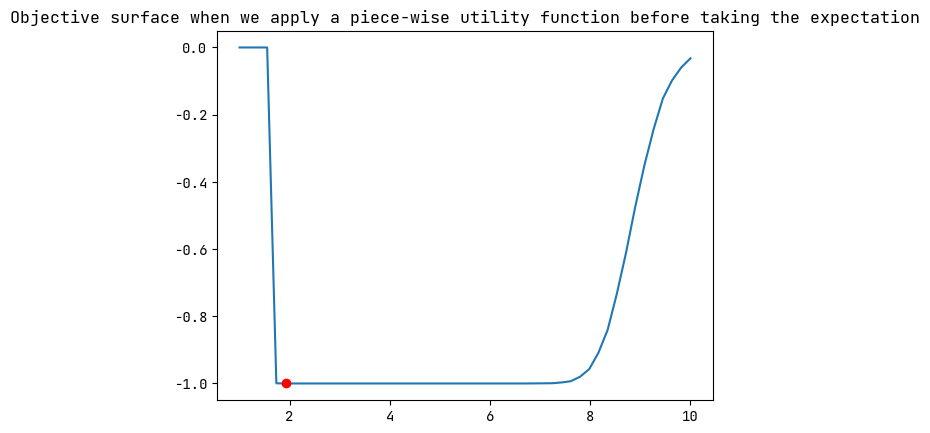

In [18]:
c = pt.as_tensor(0.3)
days = 365
unit_profit = (model.x - c)

objective = days * unit_profit * model.mu
objective = -1 * objective

objective = vectorize_over_posterior(
    outputs = [objective],
    posterior = trace.posterior,
    input_rvs=[model.a,model.b]
)[0]

# We must make at least $28,500 to say alive
# and extra profit doesn't matter
objective = pt.switch(
    pt.lt(objective, -28_500),
    -1,
    0
)

objective = pt.mean(objective)

optimizable_x = pt.dvector('opt_x')
objective = graph_replace(objective,replace={model.x:optimizable_x})
objective_grad = pt.grad(objective, wrt=optimizable_x)
objective_fn = pytensor.function([optimizable_x], [objective, objective_grad])

xs = np.linspace(1,10)
y = [float(objective_fn([x])[0]) for x in xs]

min_id = np.argmin(y)
min_val = np.min(y)
min_loc = xs[min_id]
print(min_loc)

plt.plot(xs,y)
plt.plot(min_loc,min_val,'ro')
# plt.ylim([-30_000,-25500])
plt.title("Objective surface when we apply a piece-wise utility function before taking the expectation");

## Using a distance measure to penalize objective values away from 28500

8.89795918367347


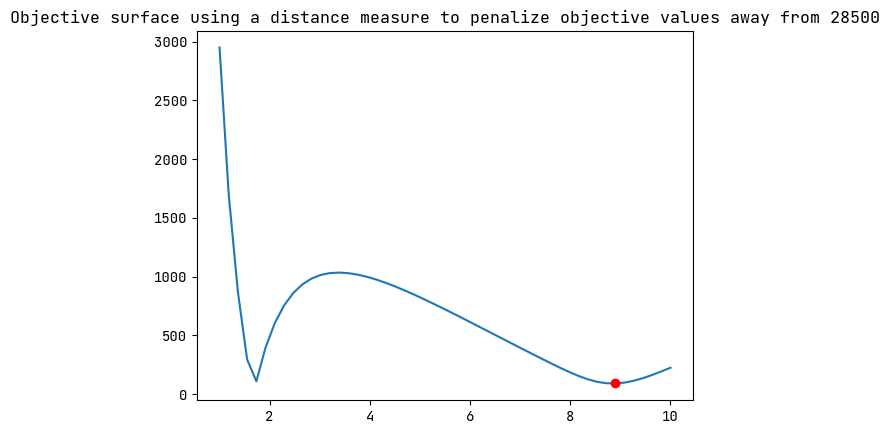

In [20]:
c = pt.as_tensor(0.3)
days = 365
unit_profit = (model.x - c)

objective = days * unit_profit * model.mu

objective = vectorize_over_posterior(
    outputs = [objective],
    posterior = trace.posterior,
    input_rvs=[model.a,model.b]
)[0]

objective = pt.abs(objective - 28_500)
objective = pt.mean(objective)

optimizable_x = pt.dvector('opt_x')
objective = graph_replace(objective,replace={model.x:optimizable_x})
objective_grad = pt.grad(objective, wrt=optimizable_x)
objective_fn = pytensor.function([optimizable_x], [objective, objective_grad])

xs = np.linspace(1,10)
y = [float(objective_fn([x])[0]) for x in xs]

min_id = np.argmin(y)
min_val = np.min(y)
min_loc = xs[min_id]
print(min_loc)

plt.plot(xs,y)
plt.plot(min_loc,min_val,'ro')
plt.title("Objective surface using a distance measure to penalize objective values away from 28500");

## Expected utility models of risk aversions

### Exponential utility

min:  -3.2585161629423145
min:  2.7082618748683953
3.0204081632653064


C:\Users\dsaun\AppData\Local\Temp\ipykernel_15284\1506642446.py:40: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdis = az.hdi(y)


Text(0.5, 1.0, 'Uncertainty in exponential utility over one year')

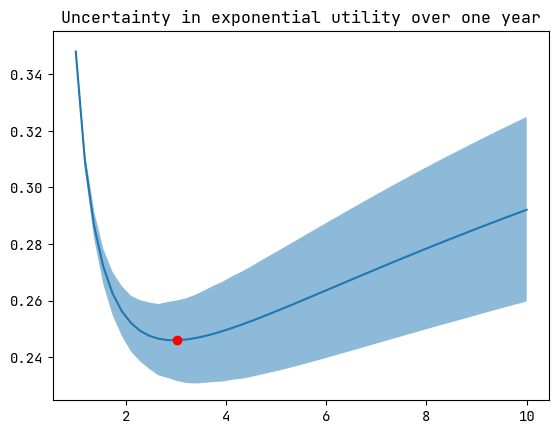

In [27]:
c = pt.as_tensor(0.3)
lam = pt.as_tensor(0.1)
days = 365
unit_profit = (model.x - c)

objective = days * unit_profit * model.mu
# rescale the problem to deal with overflow
objective = (objective - 15_000) / 1000
print("min: ", pt.min(objective).eval())
print("min: ", pt.max(objective).eval())
# apply the exponential utility function
objective = -pt.exp(-lam * objective)
objective = -1 * objective

objective = vectorize_over_posterior(
    outputs = [objective],
    posterior = trace.posterior,
    input_rvs=[model.a,model.b]
)[0]

# objective = pt.mean(objective)

optimizable_x = pt.dvector('opt_x')
objective = graph_replace(objective,replace={model.x:optimizable_x})

# objective_grad = pt.grad(objective, wrt=optimizable_x)
objective_fn = pytensor.function([optimizable_x], [objective])

xs = np.linspace(1,10)
y = [objective_fn([x])[0] for x in xs]
y = np.array(y)
y = np.reshape(y,(50,4000)).T
y_mean = y.mean(axis=0)

min_id = np.argmin(y_mean)
min_val = np.min(y_mean)
min_loc = xs[min_id]
print(min_loc)

hdis = az.hdi(y)
lower = hdis[:,0]
upper = hdis[:,1]

plt.plot(xs,y.mean(axis=0))
plt.plot(min_loc,min_val,'ro')
plt.fill_between(xs,lower,upper,alpha=0.5);
plt.title("Uncertainty in exponential utility over one year")

## Non-expected utility models of risk aversion

### Mean-variance optimization

1.5510204081632653


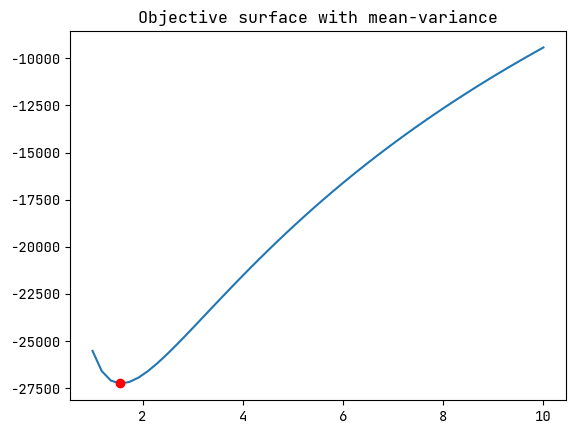

In [58]:
c = pt.as_tensor(0.3)
lam = pt.as_tensor(0.05)
days = 365
unit_profit = (model.x - c)

objective = days * unit_profit * model.mu

objective = vectorize_over_posterior(
    outputs = [objective],
    posterior = trace.posterior,
    input_rvs=[model.a,model.b]
)[0]

# the risk-penalized objective

objective = pt.mean(objective) - lam * pt.var(objective)
objective = -1 * objective

optimizable_x = pt.dvector('opt_x')
objective = graph_replace(objective,replace={model.x:optimizable_x})
objective_grad = pt.grad(objective, wrt=optimizable_x)
objective_fn = pytensor.function([optimizable_x], [objective, objective_grad])

xs = np.linspace(1,10)
y = [float(objective_fn([x])[0]) for x in xs]

min_id = np.argmin(y)
min_val = np.min(y)
min_loc = xs[min_id]
print(min_loc)

plt.plot(xs,y)
plt.plot(min_loc,min_val,'ro')
# plt.ylim([-30_000,-25500])
plt.title("Objective surface with mean-variance");

### CVaR

2.6530612244897958


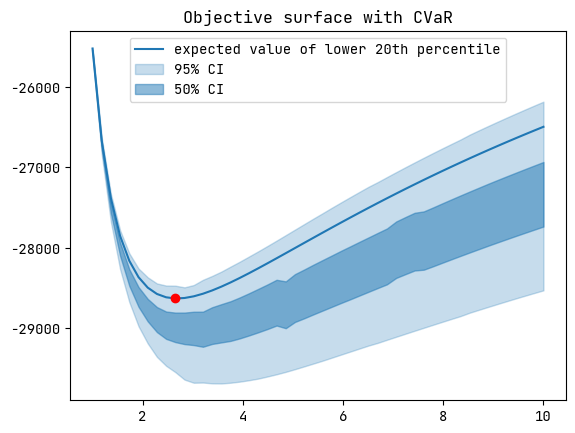

In [60]:
c = pt.as_tensor(0.3)
p = pt.as_tensor(0.20)
days = 365
unit_profit = (model.x - c)

objective = days * unit_profit * model.mu

objective = vectorize_over_posterior(
    outputs = [objective],
    posterior = trace.posterior,
    input_rvs=[model.a,model.b]
)[0]

# CVaR - drop all samples except the 5% in the tail and take the expectation
objective = objective.transpose((2,0,1))
objective = objective.flatten(ndim=(2))
objective = objective.sort(axis=1)
r = pt.floor(p * objective.shape[1])
r = pt.cast(r,"int32")
objective = objective[:,:r]

# Normal expectation minimization
objective = pt.mean(objective)
objective = -1 * objective

optimizable_x = pt.dvector('opt_x')
objective = graph_replace(objective,replace={model.x:optimizable_x})
objective_grad = pt.grad(objective, wrt=optimizable_x)
objective_fn = pytensor.function([optimizable_x], [objective, objective_grad])

xs = np.linspace(1,10)
y = [float(objective_fn([x])[0]) for x in xs]

min_id = np.argmin(y)
min_val = np.min(y)
min_loc = xs[min_id]
print(min_loc)

plt.plot(xs,y,label="expected value of lower 20th percentile")
plt.plot(min_loc,min_val,'ro')
plt.fill_between(xs,lower_95,upper_95,alpha=0.25,label="95% CI",color="tab:blue");
plt.fill_between(xs,lower_50,upper_50,alpha=0.5,label="50% CI",color="tab:blue");
plt.legend()
plt.title("Objective surface with CVaR");

# Menu of options

Utility functions
- exponential
- power
- piece-wise
- log

Not utility measures
- mean-variance
- CVaR (drop all samples except the 5% in the tail and optimize over that)
- Quantile or percentile decision rules

# Many bespoke risk-sensitive rules are equivalent to some utility function

Exponential utility:
- No natural way to specify risk-neutrality
- But you can just make it piece-wise so risk neutral is an identity function.

Text(0.5, 1.0, 'Exponential utility function')

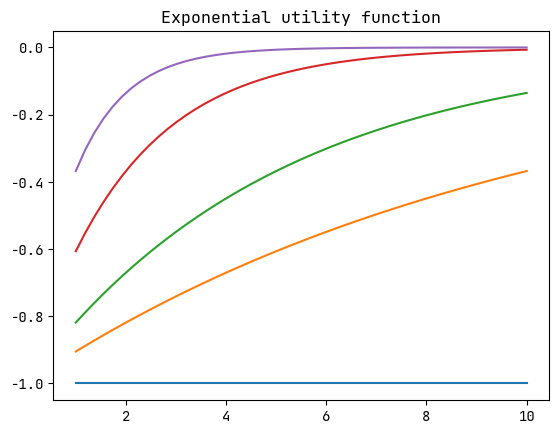

In [21]:
x = np.linspace(1,10)

lams = [0,0.1,0.2,0.5,1]
for lam in lams:
    exp_utility = -np.exp(-lam*x)
    plt.plot(x,exp_utility)
plt.title("Exponential utility function")

Quadratic utility: 
- not monotonic even with sure bets

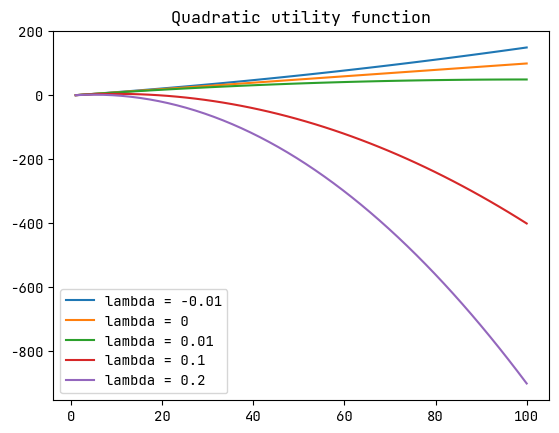

In [13]:
x = np.linspace(1,100)

lams = [-0.01,0,0.01,0.1,0.2]
for lam in lams:
    quadratic_utility = x - (lam / 2)*x**2
    plt.plot(x,quadratic_utility,label=f"lambda = {lam}")
plt.title("Quadratic utility function")
plt.legend()